<a href="https://colab.research.google.com/github/Yasir-Aladwani/medical-insurance-cost-analysis/blob/main/medical_insurance_cost_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Insurance Cost Analysis and Prediction
This project combines exploratory data analysis, visualization, and machine learning techniques to analyze and predict medical insurance charges using demographic and lifestyle features.

##  Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [3]:
# Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

##  Load dataset

In [4]:
df = pd.read_csv("/content/insurance.csv")

##  Display basic information

In [5]:
print("First 5 rows:")
print(df.head())
print("\nShape of dataset:", df.shape)

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Shape of dataset: (1338, 7)


In [6]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [7]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [8]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [9]:
print("\nDupicated values:")
print(df.duplicated().sum())


Dupicated values:
1


In [10]:
# Remove duplicate rows
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [11]:
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


##  Data Understanding

In [12]:
print("\nUnique values in categorical columns:")
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Unique values in categorical columns:

sex:
sex
male      675
female    662
Name: count, dtype: int64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## EDA Question 1:
## What is the distribution of medical insurance charges?

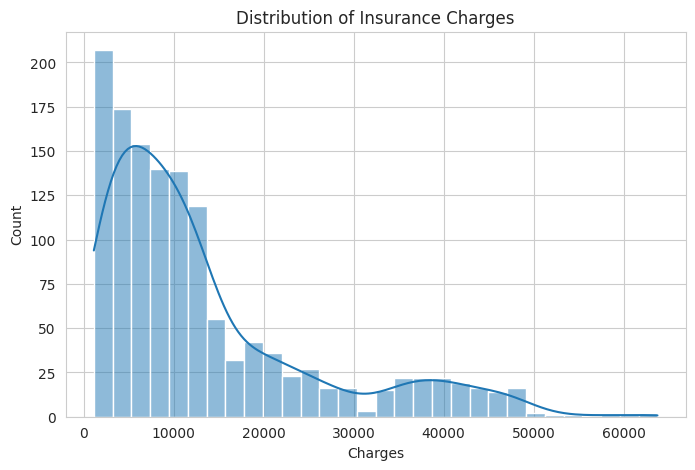

In [13]:
plt.figure()
sns.histplot(df["charges"], bins=30, kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

**Insight:**

- The distribution of medical insurance charges is right-skewed (positively skewed).
- Most individuals have relatively low medical costs, while a smaller number of people experience very high charges.
________________________________________________________________________________

## EDA Question 2:
## Does age affect insurance charges?

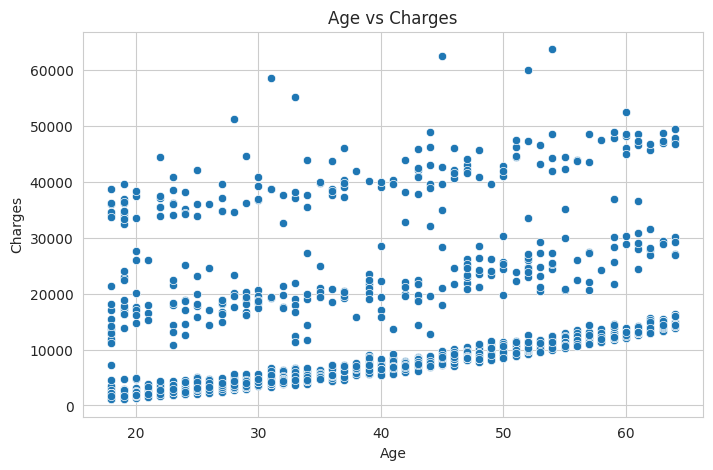

In [14]:
plt.figure()
sns.scatterplot(data=df, x="age", y="charges")
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

**Insight:**

- The scatter plot shows a positive relationship between age and medical
charges, suggesting that healthcare costs generally increase as individuals grow older.

- The plot also shows distinct cost clusters, suggesting that other factors such as smoking status may strongly influence insurance charges.
________________________________________________________________________________

## EDA Question 3:
## Do smokers pay higher insurance charges?

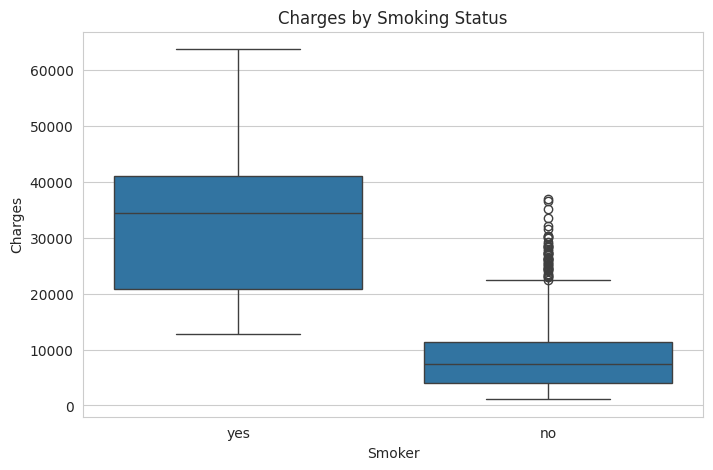


Average charges by smoking status:
smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64


In [15]:
plt.figure()
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

smoker_mean = df.groupby("smoker")["charges"].mean()
print("\nAverage charges by smoking status:")
print(smoker_mean)

**Insight:**
- The boxplot clearly shows that smokers have substantially higher insurance charges than non-smokers.
- This suggests that smoking is one of the strongest factors affecting medical costs in the dataset.
________________________________________________________________________________

## EDA Question 4:
## Does BMI affect insurance charges?

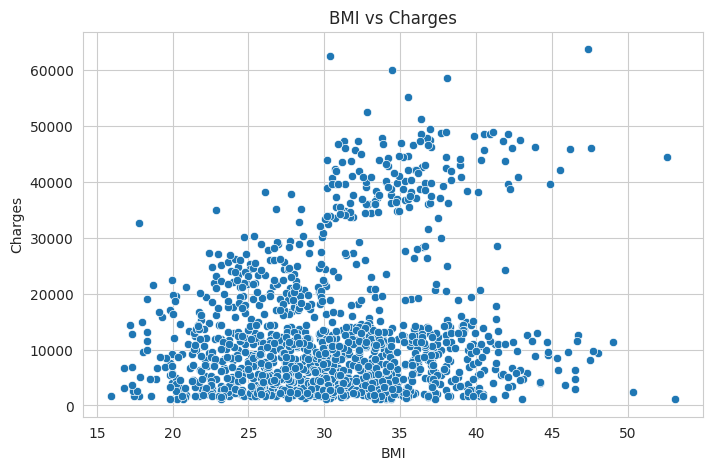

In [16]:
plt.figure()
sns.scatterplot(data=df, x="bmi", y="charges")
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

**Insight:**
- The scatter plot suggests that higher BMI values are associated with increased insurance charges, although the relationship is not perfectly linear.
- The presence of high-cost clusters suggests that BMI alone does not explain the variation in charges, and other factors such as smoking likely play a stronger role.
________________________________________________________________________________

## EDA Question 5:
## Does number of children affect insurance charges?

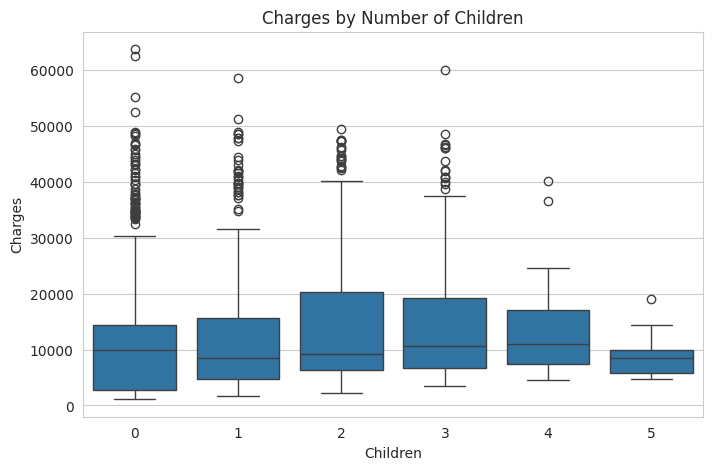


Average charges by number of children:
children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


In [17]:
plt.figure()
sns.boxplot(data=df, x="children", y="charges")
plt.title("Charges by Number of Children")
plt.xlabel("Children")
plt.ylabel("Charges")
plt.show()

children_mean = df.groupby("children")["charges"].mean()
print("\nAverage charges by number of children:")
print(children_mean)

**Insight:**
- Insurance charges slightly increase for individuals with 2 or 3 children, but overall the number of children does not show a strong influence on medical costs.
- Compared to smoking and age, the number of children has a relatively weak effect on insurance charges.
________________________________________________________________________________

## EDA Question 6:
## Does Gender affect insurance charges?

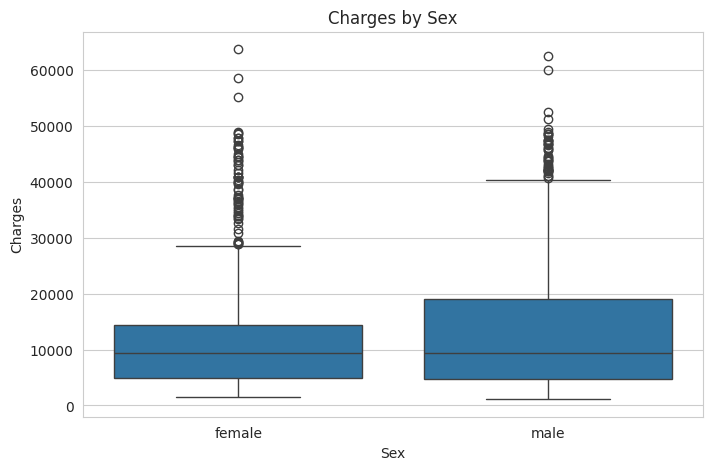


Average charges by sex:
sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64


In [18]:
plt.figure()
sns.boxplot(data=df, x="sex", y="charges")
plt.title("Charges by Sex")
plt.xlabel("Sex")
plt.ylabel("Charges")
plt.show()

sex_mean = df.groupby("sex")["charges"].mean()
print("\nAverage charges by sex:")
print(sex_mean)

**Insight:**
- The boxplot shows that medical insurance charges are relatively similar between males and females.
- Gender does not appear to be a strong predictor of medical insurance charges in this dataset.
________________________________________________________________________________

## EDA Question 7:
## Does region affect insurance charges?

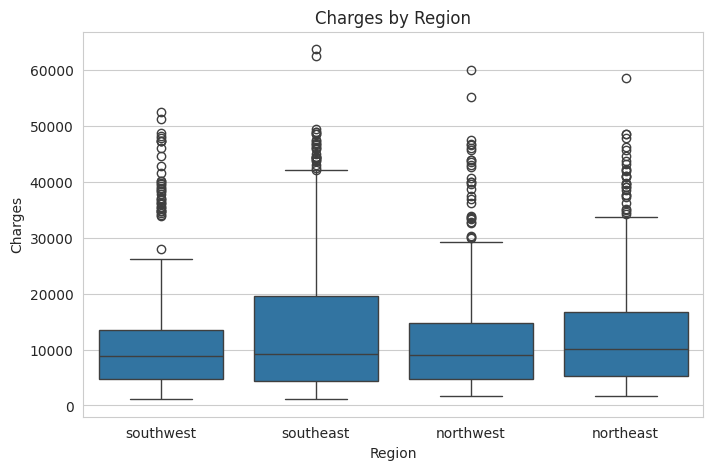


Average charges by region:
region
southeast    14735.411438
northeast    13406.384516
northwest    12450.840844
southwest    12346.937377
Name: charges, dtype: float64


In [19]:
plt.figure()
sns.boxplot(data=df, x="region", y="charges")
plt.title("Charges by Region")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()

region_mean = df.groupby("region")["charges"].mean().sort_values(ascending=False)
print("\nAverage charges by region:")
print(region_mean)

**Insight:**
- While all regions show a similar distribution of charges, the southeast region has the highest average insurance costs compared to the other regions.
- Region appears to have a relatively minor effect on insurance charges compared to factors such as smoking or age.
________________________________________________________________________________

## EDA Question 8:
## Do age and smoking together increase charges?

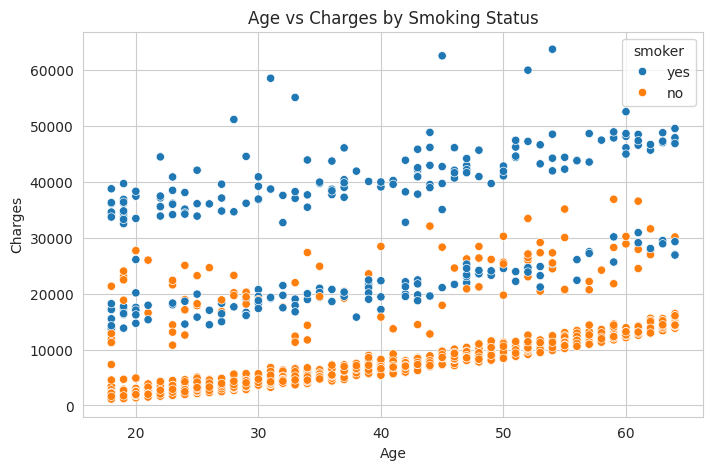

In [20]:
plt.figure()
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Age vs Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

**Insight:**
- The plot shows that smokers consistently have much higher insurance charges than non-smokers across all age groups.
- Older smokers experience the highest medical insurance charges in the dataset
- The clear separation between smokers and non-smokers highlights smoking as the strongest factor driving high medical insurance costs.
________________________________________________________________________________

## EDA Question 9:
## Are there outliers in medical insurance charges?

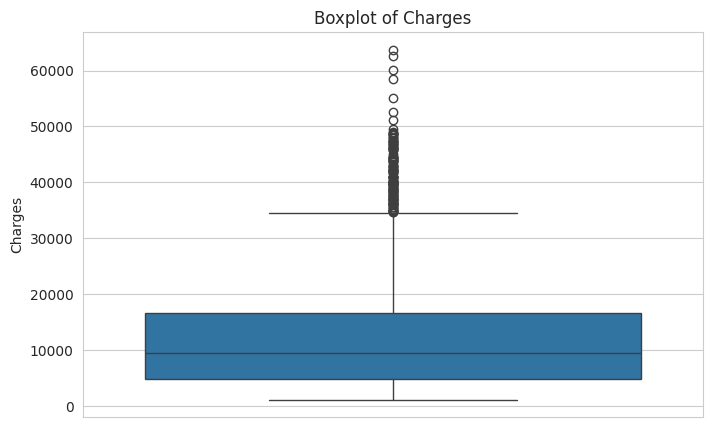


Number of outliers in charges: 139


In [21]:
plt.figure()
sns.boxplot(y=df["charges"])
plt.title("Boxplot of Charges")
plt.ylabel("Charges")
plt.show()

Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["charges"] < lower_bound) | (df["charges"] > upper_bound)]
print("\nNumber of outliers in charges:", outliers.shape[0])

**Insight:**
- These outliers were retained since they represent real-world high medical expenses rather than incorrect data.

In [22]:
# Top 10 highest charges
top10_outliers = outliers.sort_values(by="charges", ascending=False).head(10)

top10_outliers

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
1300,45,male,30.360,0,yes,southeast,62592.87309
1230,52,male,34.485,3,yes,northwest,60021.39897
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209
1146,60,male,32.800,0,yes,southwest,52590.82939
34,28,male,36.400,1,yes,southwest,51194.55914
1241,64,male,36.960,2,yes,southeast,49577.66240
1062,59,male,41.140,1,yes,southeast,48970.24760
488,44,female,38.060,0,yes,southeast,48885.13561


**Insight:**
- All top 10 highest charges belong to smokers.
- Most individuals have BMI above 30.
- Ages mainly range between 30–60 years.
- Several individuals are from the southeast region.


## EDA Question 10:
## Which variable is most associated with charges?

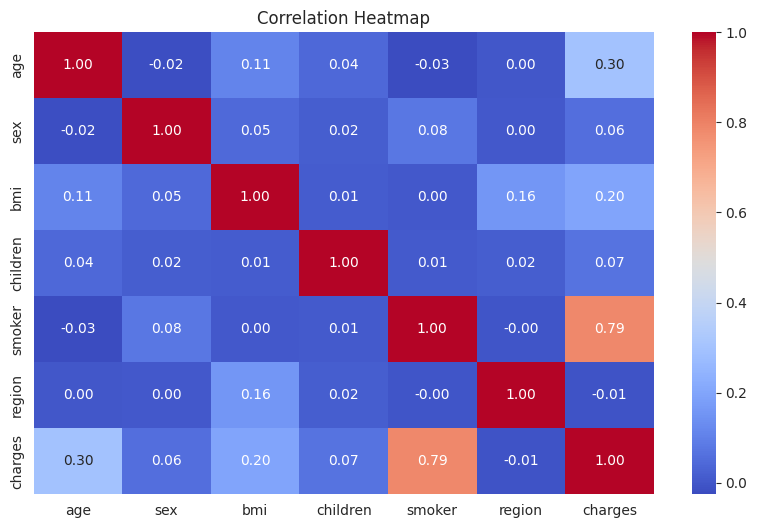


Correlation with charges:
charges     1.000000
smoker      0.787234
age         0.298308
bmi         0.198401
children    0.067389
sex         0.058044
region     -0.006547
Name: charges, dtype: float64


In [23]:
# Copy dataframe for encoding
df_encoded = df.copy()

# Encode categorical columns
label_encoders = {}
for col in df_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Correlation matrix
corr = df_encoded.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with charges:")
print(corr["charges"].sort_values(ascending=False))

**Insight:**
- Smoking is the strongest predictor of medical insurance costs.
- Older individuals tend to have higher medical costs.
- Higher BMI is associated with moderately higher charges.
- Gender, region, and number of children have relatively weak effects on insurance costs.
________________________________________________________________________________

## Preparing Data for Machine Learning

In [24]:
# Features and target
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model 1: Linear Regression (Baseline Model)

In [25]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("\n=== Linear Regression Results ===")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))


=== Linear Regression Results ===
MAE: 4182.353155288296
RMSE: 5957.608799816459
R2 Score: 0.8068466322629112


## Model 2: Random Forest (Proposed Model)

**Why Random Forest?**
- Random Forest can capture nonlinear relationships between features and the target variable.
- It is also more robust to outliers compared to linear models

In [26]:
rf_model = RandomForestRegressor(random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest Results ===")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))



=== Random Forest Results ===
MAE: 2546.224652592164
RMSE: 4625.546730003947
R2 Score: 0.8835647538322066


### Feature Importance Analysis (Random Forest)

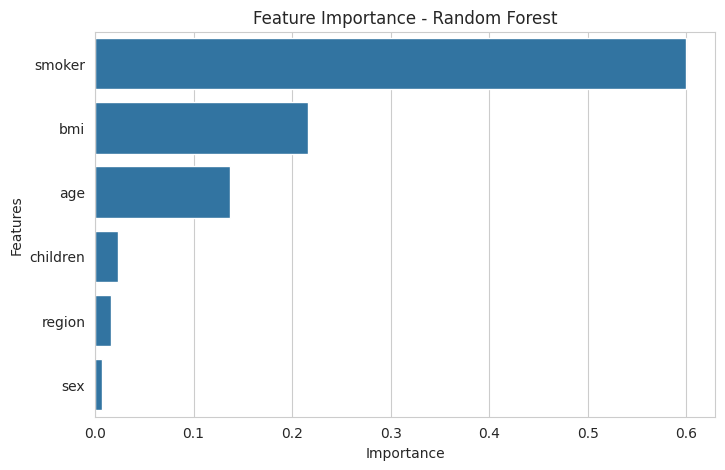


Most important features:
smoker      0.599299
bmi         0.216442
age         0.137458
children    0.023413
region      0.016152
sex         0.007236
dtype: float64


In [27]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure()
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

print("\nMost important features:")
print(feature_importance)

**Insight:**
- These results confirm the patterns observed during the EDA stage

## Model Comparison: Linear Regression vs Random Forest



In [32]:
# Performance Metrics Table
metrics_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

metrics_df

,Model,MAE,RMSE,R2
0,Linear Regression,4182.353155,5957.60880,0.806847
1,Random Forest,2546.224653,4625.54673,0.883565


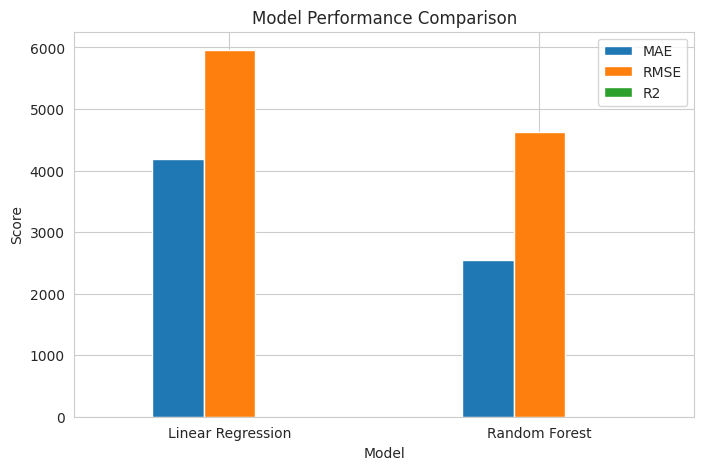

In [33]:
# Model Performance Comparison Plot
metrics_df.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

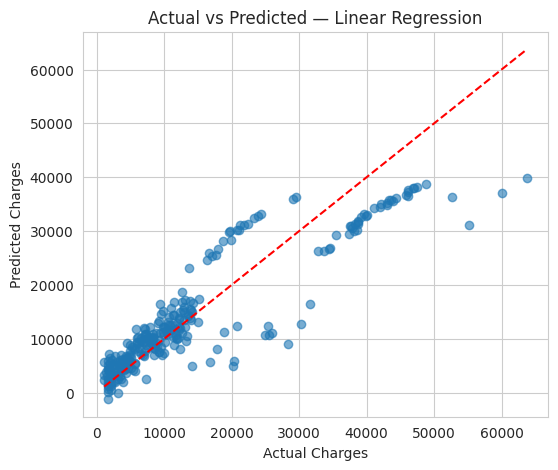

In [34]:
# Actual vs Predicted — Linear Regression
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted — Linear Regression")

plt.show()

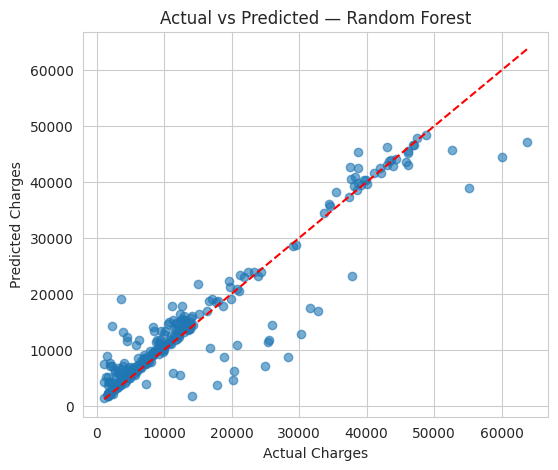

In [35]:
# Actual vs Predicted — Random Forest
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted — Random Forest")

plt.show()

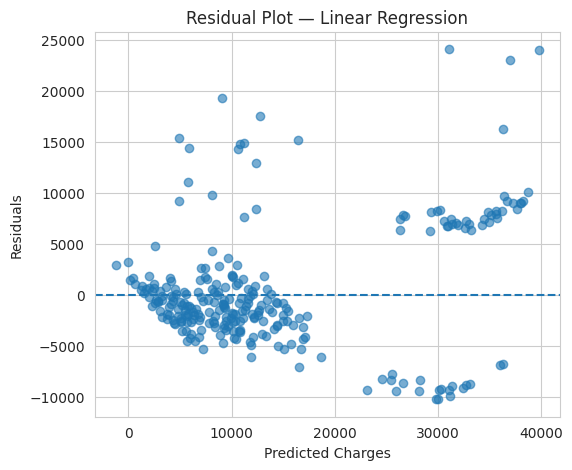

In [36]:
# Residual Plot — Linear Regression
lr_residuals = y_test - y_pred_lr

plt.figure(figsize=(6,5))

plt.scatter(y_pred_lr, lr_residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot — Linear Regression")

plt.show()

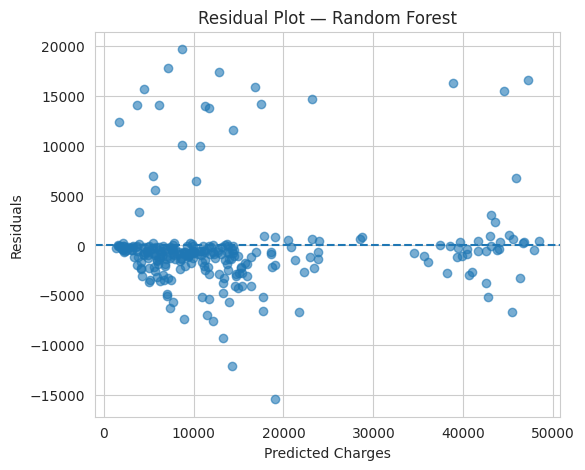

In [37]:
# Residual Plot — Random Forest
rf_residuals = y_test - y_pred_rf

plt.figure(figsize=(6,5))

plt.scatter(y_pred_rf, rf_residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot — Random Forest")

plt.show()

## Conclusion

This project explored the key factors influencing medical insurance charges using exploratory data analysis and machine learning techniques. The analysis revealed that smoking, age, and BMI are the most influential variables affecting insurance costs. A Random Forest model was then developed and compared with a Linear Regression baseline model. The results showed that Random Forest achieved better predictive performance, demonstrating its effectiveness in capturing complex relationships within the data.